In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from matplotlib import pyplot as plt

In [ ]:
import pandas as pd
df =pd.read_csv("/content/bank-full.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


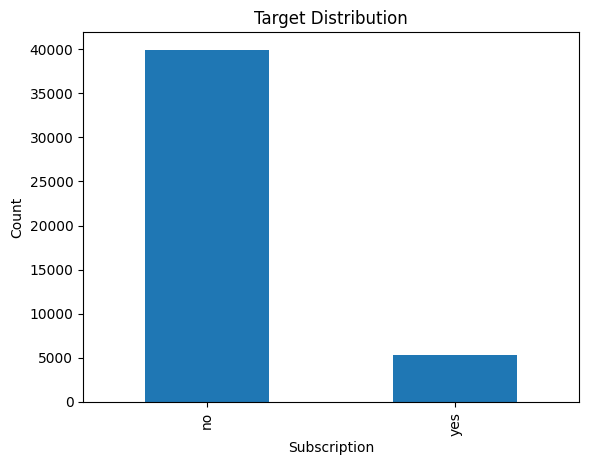

In [ ]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')

plt.title("Target Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

In [ ]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


encoding


In [ ]:
X =df.drop("y",axis=1)
Y = df["y"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)
print(Y)

[0 0 0 ... 1 0 0]


In [ ]:
# One-Hot Encode only the features
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X.select_dtypes(include="object").columns) # we check there is no object category left

Index([], dtype='object')


In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size =0.2,random_state =42)

In [ ]:
model = XGBClassifier(random_state=42)

In [ ]:
model.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [ ]:
accuracy = accuracy_score(Y_test,y_pred)
print("Accuracy :",accuracy*100)
cm = confusion_matrix(Y_test,y_pred)
print("Matrix :",cm)
cl = classification_report(Y_test,y_pred)
print("Report :",cl)

Accuracy : 90.36824062811014
Matrix : [[7638  314]
 [ 557  534]]
Report :               precision    recall  f1-score   support

           0       0.93      0.96      0.95      7952
           1       0.63      0.49      0.55      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.72      0.75      9043
weighted avg       0.90      0.90      0.90      9043



Recall is more important here rather than precision

## **GridSearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1]
}
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7952
           1       0.66      0.48      0.55      1091

    accuracy                           0.91      9043
   macro avg       0.79      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



In [ ]:
print(grid.best_score_)

0.484754242579034


scale_pos_weight

scale_pos_weight = 39922 / 5289
                   ≈ 7.55

In [ ]:
model_weighted = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=7.55
)

model_weighted.fit(X_train, Y_train)

y_pred_weighted = model_weighted.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.97      0.88      0.93      7952
           1       0.49      0.81      0.61      1091

    accuracy                           0.88      9043
   macro avg       0.73      0.85      0.77      9043
weighted avg       0.91      0.88      0.89      9043



Recall: 49% → 81% 🚀
Precision: 63% → 49%

This is called the Precision–Recall trade-off.

Increase attention to Yes
          ↓
More Yes predictions
          ↓
Recall ↑
          ↓
But false positives ↑
          ↓
Precision ↓

# **Threshold Tuning.**




Instead of accepting XGBoost's default:

Probability ≥ 0.50 → Yes
Probability < 0.50 → No

Customer-a miss panna koodadhu → Recall important → threshold lower pannuvom.

In [ ]:
y_prob = model_weighted.predict_proba(X_test)[:, 1]
print(y_prob)  #probability of YES for every customer

[0.00120138 0.02633918 0.3749854  ... 0.00247137 0.00145665 0.00485533]


In [ ]:
threshold = 0.40

y_pred_threshold = (y_prob >= threshold).astype(int)

In [ ]:
accuracy = accuracy_score(Y_test, y_pred_threshold)
print("Accuracy :",accuracy*100)
cm = confusion_matrix(Y_test, y_pred_threshold)
print("Matrix :",cm)
cl = classification_report(Y_test, y_pred_threshold)
print("Report :",cl)

Accuracy : 85.90069667145859
Matrix : [[6848 1104]
 [ 171  920]]
Report :               precision    recall  f1-score   support

           0       0.98      0.86      0.91      7952
           1       0.45      0.84      0.59      1091

    accuracy                           0.86      9043
   macro avg       0.72      0.85      0.75      9043
weighted avg       0.91      0.86      0.88      9043



Baseline:
Recall = 49%

Weighted model:
Recall = 81%

Weighted + threshold 0.40:
Recall = 84%

# **Feature Engineering:**

Existing data → create a meaningful new feature → test whether it actually helps the model.

In [ ]:
df["total_contacts"] = df["campaign"] + df["previous"]

In [ ]:
df["contact_intensity"] = df["duration"] / df["campaign"]